# Phase 1 — Data Collection
## Financial News Sentiment Intelligence System

**Goal:** Build a robust data collection pipeline that fetches
real financial news from Yahoo Finance for 5 companies and saves
it to a structured CSV for downstream processing.

**Output:** `data/raw/all_news.csv`

**Why this matters:** Every ML model is only as good as its data.
Before we can score sentiment or predict prices, we need clean,
validated, well-structured raw data. This notebook builds that foundation.

In [5]:
# ── environment check ─────────────────────────────────────
# why: confirms everything is installed before running
# the full pipeline. Saves you from a crash halfway through.
# This is called a "preflight check" — pilots do it,

import sys
import os

# add project root to path so notebook can find src/ and config.py
# notebooks/ is a subfolder, so we go one level up with ".."
sys.path.insert(0, os.path.abspath(".."))

# import our modules
from config import COMPANIES, RAW_DATA_PATH
from src.utils import get_logger
from src.data_collector import collect_all_companies

# check Python version
print(f"Python version : {sys.version.split()[0]}")

# check all key libraries
import yfinance, pandas, numpy
print(f"yfinance       : {yfinance.__version__}")
print(f"pandas         : {pandas.__version__}")
print(f"numpy          : {numpy.__version__}")

# confirm config loaded
print(f"\nCompanies      : {COMPANIES}")
print(f"Save path      : {RAW_DATA_PATH}")

print("\n✅ Preflight check passed. Ready to collect data.")

Python version : 3.11.7
yfinance       : 1.3.0
pandas         : 3.0.3
numpy          : 2.4.4

Companies      : ['AAPL', 'GOOGL', 'META', 'AMZN', 'MSFT']
Save path      : data\raw\all_news.csv

✅ Preflight check passed. Ready to collect data.


## Step 1 — Run the collection pipeline

Calling `collect_all_companies()` from `src/data_collector.py`.

This single function call runs the entire pipeline:
fetch → parse → validate → save.

Watch the logs below — they tell you exactly what is happening
at each step. Notice the rejection rate — this is your first
data quality metric.

In [2]:
# ── run the full collection pipeline ──────────────────────
# one function call — that is the power of building src/ modules

df = collect_all_companies()

print(f"\n{'='*50}")
print(f"Collection complete.")
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

2026-05-14 04:44:33 | src.data_collector   | INFO     | =======================================================
2026-05-14 04:44:33 | src.data_collector   | INFO     | Starting data collection pipeline
2026-05-14 04:44:33 | src.data_collector   | INFO     | Companies: ['AAPL', 'GOOGL', 'META', 'AMZN', 'MSFT']
2026-05-14 04:44:33 | src.data_collector   | INFO     | =======================================================
2026-05-14 04:44:34 | src.data_collector   | INFO     | Fetched 10 raw articles for AAPL
2026-05-14 04:44:34 | src.data_collector   | INFO     | Fetched 10 raw articles for GOOGL
2026-05-14 04:44:34 | src.data_collector   | INFO     | Fetched 10 raw articles for META
2026-05-14 04:44:34 | src.data_collector   | INFO     | Fetched 10 raw articles for AMZN
2026-05-14 04:44:34 | src.data_collector   | INFO     | Fetched 10 raw articles for MSFT
2026-05-14 04:44:35 | src.data_collector   | INFO     | 
── Collection Summary ──────────────────
--- Logging error ---
Traceback (


Collection complete.
Dataset shape: 50 rows × 6 columns


## Step 2 — Inspect the raw data

Before saving any data to processed/, we always inspect it.
The questions we ask:
- Does the shape match expectations?
- Are there missing values?
- Are the dates in the right format?
- Do the headlines look like real financial news?

This inspection is what you describe in interviews when asked
"how do you validate incoming data?"

In [3]:
import pandas as pd

# reload from CSV — confirms the save worked correctly
df = pd.read_csv(f"../{RAW_DATA_PATH}")

print("─── SHAPE ────────────────────────────────")
print(f"  {df.shape[0]} rows × {df.shape[1]} columns\n")

print("─── COLUMNS ──────────────────────────────")
for col in df.columns:
    dtype = df[col].dtype
    nulls = df[col].isnull().sum()
    print(f"  {col:<12} dtype={str(dtype):<10} nulls={nulls}")

print("\n─── ARTICLES PER COMPANY ─────────────────")
print(df.groupby("ticker").size().to_string())

print("\n─── DATE RANGE ───────────────────────────")
print(f"  Earliest : {df['date'].min()}")
print(f"  Latest   : {df['date'].max()}")

print("\n─── SAMPLE HEADLINES ─────────────────────")
for _, row in df.sample(5, random_state=42).iterrows():
    print(f"  [{row['ticker']}] {row['title'][:70]}")

print("\n─── FULL DATAFRAME PREVIEW ───────────────")
df.head(10)

─── SHAPE ────────────────────────────────
  50 rows × 6 columns

─── COLUMNS ──────────────────────────────
  ticker       dtype=str        nulls=0
  title        dtype=str        nulls=0
  summary      dtype=str        nulls=0
  date         dtype=str        nulls=0
  url          dtype=str        nulls=0
  date_clean   dtype=str        nulls=0

─── ARTICLES PER COMPANY ─────────────────
ticker
AAPL     10
AMZN     10
GOOGL    10
META     10
MSFT     10

─── DATE RANGE ───────────────────────────
  Earliest : 11 May 2026, 02:03 PM UTC
  Latest   : 11 May 2026, 02:03 PM UTC

─── SAMPLE HEADLINES ─────────────────────
  [GOOGL] Top Midday Stories: Moderna Working on Hantavirus Vaccine, Shares Rise
  [AMZN] AI Wins Have Alphabet Poised to Become World’s Biggest Company
  [AMZN] The $1 trillion club's new members are powering the AI boom: Chart of 
  [MSFT] Microsoft CEO Takes Stand in Third Week of Elon Musk Megatrial Against
  [GOOGL] Alphabet Taps Yen Bond Market To Support Expanding 

,ticker,title,summary,date,url,date_clean
0,AAPL,"Memory chip stocks hit record highs, pharma re...",Market Catalysts Host Julie Hyman and Yahoo Fi...,"11 May 2026, 02:03 PM UTC",https://finance.yahoo.com/video/memory-chip-st...,2026-05-11
1,AAPL,The $1 trillion club's new members are powerin...,Market royalty is getting a hardware makeover.,"11 May 2026, 02:03 PM UTC",https://finance.yahoo.com/markets/article/the-...,2026-05-11
2,AAPL,Apple delivers surprise win in Big Tech’s AI s...,Apple (AAPL) is spending much of the artificia...,"11 May 2026, 02:03 PM UTC",https://www.thestreet.com/investing/apple-deli...,2026-05-11
3,AAPL,Apple-Intel preliminary chip deal seen as posi...,"Apple Inc (NASDAQ:AAPL, XETRA:APC) and Intel C...","11 May 2026, 02:03 PM UTC",https://www.proactiveinvestors.com/companies/n...,2026-05-11
4,AAPL,Asset Manager Sells 1.2 Million Bond ETF Share...,This ETF tracks a portfolio of U.S. Treasury b...,"11 May 2026, 02:03 PM UTC",https://www.fool.com/coverage/filings/2026/05/...,2026-05-11
5,AAPL,Apple Gets a Warning From Nintendo Memory-Chip...,Nintendo stock dropped after it warned it woul...,"11 May 2026, 02:03 PM UTC",https://www.barrons.com/articles/apple-stock-m...,2026-05-11
6,AAPL,"Elon Musk, Apple's Cook and Boeing CEO going t...","Elon Musk, Apple's Tim Cook, GE Aerospace's La...","11 May 2026, 02:03 PM UTC",https://finance.yahoo.com/sectors/technology/a...,2026-05-11
7,AAPL,The Hidden Drag of SPY’s Outdated UIT Structur...,SPDR S&P 500 ETF Trust (NYSEARCA:SPY) and Vang...,"11 May 2026, 02:03 PM UTC",https://247wallst.com/investing/2026/05/11/the...,2026-05-11
8,AAPL,Should You Buy Apple Stock Before June 8?,The company's annual Worldwide Developers Conf...,"11 May 2026, 02:03 PM UTC",https://www.fool.com/investing/2026/05/11/shou...,2026-05-11
9,AAPL,Intel Stock Rises on Report of Second Huge Chi...,Intel stock was gaining on a report it could b...,"11 May 2026, 02:03 PM UTC",https://www.barrons.com/articles/intel-stock-p...,2026-05-11


## Step 3 — Data quality assessment

A professional data quality check asks three questions:

1. **Completeness** — are all fields populated?
2. **Consistency** — are dates in the same format? Tickers uppercase?
3. **Validity** — do headlines look like real financial news?

Document your findings below.

In [4]:
print("─── COMPLETENESS ─────────────────────────")
missing = df.isnull().sum()
total   = len(df)
for col, count in missing.items():
    pct = count / total * 100
    status = "✅" if count == 0 else "⚠️ "
    print(f"  {status} {col:<12}: {count} missing ({pct:.1f}%)")

print("\n─── CONSISTENCY ──────────────────────────")
# are all tickers uppercase?
tickers_clean = df["ticker"].str.isupper().all()
print(f"  {'✅' if tickers_clean else '❌'} All tickers uppercase: {tickers_clean}")

# are all dates in YYYY-MM-DD format?
date_format_ok = df["date"].str.match(r"\d{4}-\d{2}-\d{2}").all()
print(f"  {'✅' if date_format_ok else '❌'} All dates YYYY-MM-DD: {date_format_ok}")

# any duplicate headlines?
dupes = df.duplicated(subset=["title"]).sum()
print(f"  {'✅' if dupes == 0 else '⚠️ '} Duplicate headlines: {dupes}")

print("\n─── VALIDITY ─────────────────────────────")
# headline word count distribution
df["title_words"] = df["title"].str.split().str.len()
print(f"  Headline word count:")
print(f"    min    : {df['title_words'].min()}")
print(f"    mean   : {df['title_words'].mean():.1f}")
print(f"    max    : {df['title_words'].max()}")
short = (df["title_words"] < 5).sum()
print(f"  Headlines under 5 words: {short}")

─── COMPLETENESS ─────────────────────────
  ✅ ticker      : 0 missing (0.0%)
  ✅ title       : 0 missing (0.0%)
  ✅ summary     : 0 missing (0.0%)
  ✅ date        : 0 missing (0.0%)
  ✅ url         : 0 missing (0.0%)
  ✅ date_clean  : 0 missing (0.0%)

─── CONSISTENCY ──────────────────────────
  ✅ All tickers uppercase: True
  ❌ All dates YYYY-MM-DD: False
  ⚠️  Duplicate headlines: 16

─── VALIDITY ─────────────────────────────
  Headline word count:
    min    : 7
    mean   : 11.8
    max    : 22
  Headlines under 5 words: 0


## Step 4 — Save and commit

Raw data saved to `data/raw/all_news.csv`.

**Key decisions documented:**
- Raw data is saved exactly as collected — never modified
- Validation happened before saving (rejected articles logged)
- One CSV per collection run — we will append in production

**Next phase:** EDA — we will explore patterns in this data,
visualise headline sentiment themes, and prepare it for
FinBERT scoring.

In [1]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath(".."))

import config
importlib.reload(config)

import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

from config import BASE_DIR, COMPANIES, SENTIMENT_MODEL, SENTIMENT_BATCH_SIZE

# ── collect news across a wider date range ─────────────
# yfinance.Ticker.news returns the most recent articles
# To get historical coverage we use the search endpoint
# with different date windows

print("Collecting extended news dataset...")
print("This may take 2-3 minutes...")
print()

all_articles = []

for symbol in COMPANIES:
    ticker = yf.Ticker(symbol)

    # get news — yfinance returns up to 10 most recent
    news = ticker.news
    print(f"  {symbol}: {len(news)} articles")

    for article in news:
        content   = article.get("content", {})
        title     = content.get("title", "No Title")
        summary   = content.get("summary", "No Summary")
        canonical = content.get("canonicalUrl", {})
        url       = canonical.get("url", "")
        raw_date  = content.get("pubDate", "")

        try:
            dt       = datetime.strptime(raw_date, "%Y-%m-%dT%H:%M:%SZ")
            date_str = dt.strftime("%d %B %Y, %I:%M %p UTC")
            date_clean = dt.strftime("%Y-%m-%d")
        except:
            date_str   = "Unknown"
            date_clean = "unknown"

        all_articles.append({
            "ticker"    : symbol,
            "title"     : title,
            "summary"   : summary,
            "date"      : date_str,
            "date_clean": date_clean,
            "url"       : url,
        })

df_new = pd.DataFrame(all_articles)
df_new = df_new[df_new["date_clean"] != "unknown"]
df_new = df_new.drop_duplicates(subset=["title"])

print(f"\nTotal articles: {len(df_new)}")
print(f"Date range: {df_new['date_clean'].min()} to {df_new['date_clean'].max()}")
print(f"Unique dates: {df_new['date_clean'].nunique()}")
print(f"\nArticles per company:")
print(df_new.groupby("ticker").size().to_string())

This may take 2-3 minutes...

  AAPL: 10 articles
  GOOGL: 10 articles
  META: 10 articles
  AMZN: 10 articles
  MSFT: 10 articles

Total articles: 38
Date range: 2026-06-02 to 2026-06-03
Unique dates: 2

Articles per company:
ticker
AAPL     10
AMZN      7
GOOGL     9
META      4
MSFT      8


In [2]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath(".."))
import config
importlib.reload(config)

import yfinance as yf
import pandas as pd
from datetime import datetime
from config import COMPANIES, RAW_DATA_PATH

print(f"Collecting news for: {COMPANIES}")
print()

all_articles = []

for symbol in COMPANIES:
    ticker   = yf.Ticker(symbol)
    raw_news = ticker.news
    count    = 0

    for article in raw_news:
        content   = article.get("content", {})
        title     = content.get("title", "No Title")
        summary   = content.get("summary", "No Summary")
        canonical = content.get("canonicalUrl", {})
        url       = canonical.get("url", "")
        raw_date  = content.get("pubDate", "")

        try:
            dt         = datetime.strptime(raw_date, "%Y-%m-%dT%H:%M:%SZ")
            date_str   = dt.strftime("%d %B %Y, %I:%M %p UTC")
            date_clean = dt.strftime("%Y-%m-%d")
        except Exception:
            date_str   = "Unknown"
            date_clean = "unknown"

        all_articles.append({
            "ticker"    : symbol,
            "title"     : title,
            "summary"   : summary,
            "date"      : date_str,
            "date_clean": date_clean,
            "url"       : url,
        })
        count += 1

    print(f"  {symbol}: {count} articles")

# build dataframe
df_new = pd.DataFrame(all_articles)
df_new = df_new[df_new["date_clean"] != "unknown"]

print(f"\nNew articles collected : {len(df_new)}")
print(f"New dates              : {sorted(df_new['date_clean'].unique())}")

# ── load existing and combine ──────────────────────────────
if os.path.exists(RAW_DATA_PATH):
    df_existing = pd.read_csv(RAW_DATA_PATH)
    print(f"\nExisting articles      : {len(df_existing)}")
    print(f"Existing dates         : {sorted(df_existing['date_clean'].unique())}")

    df_combined = pd.concat(
        [df_existing, df_new], ignore_index=True
    )
else:
    print("\nNo existing file — creating fresh")
    df_combined = df_new

# deduplicate on title
before = len(df_combined)
df_combined = df_combined.drop_duplicates(
    subset=["title"], keep="first"
)
df_combined = df_combined.sort_values(
    ["ticker", "date_clean"]
).reset_index(drop=True)

print(f"\nCombined total         : {len(df_combined)}")
print(f"Duplicates removed     : {before - len(df_combined)}")
print(f"Final unique dates     : {sorted(df_combined['date_clean'].unique())}")
print(f"Articles per company   :")
print(df_combined.groupby("ticker").size().to_string())

# ── SAVE — this is the step that was missing ───────────────
os.makedirs(os.path.dirname(RAW_DATA_PATH), exist_ok=True)
df_combined.to_csv(RAW_DATA_PATH, index=False)
print(f"\n✅ SAVED to {RAW_DATA_PATH}")

# verify save worked
verify = pd.read_csv(RAW_DATA_PATH)
print(f"✅ VERIFIED: {len(verify)} rows in file")
print(f"✅ Dates in file: {sorted(verify['date_clean'].unique())}")


  AAPL: 10 articles
  GOOGL: 10 articles
  META: 10 articles
  AMZN: 10 articles
  MSFT: 10 articles

New articles collected : 50
New dates              : ['2026-06-06', '2026-06-07']

Existing articles      : 50
Existing dates         : ['2026-05-11']

Combined total         : 69
Duplicates removed     : 31
Final unique dates     : ['2026-05-11', '2026-06-06', '2026-06-07']
Articles per company   :
ticker
AAPL     20
AMZN     12
GOOGL    15
META     13
MSFT      9

✅ SAVED to d:\Financial-News-Sentiment-Intelligence-System\data\raw\all_news.csv
✅ VERIFIED: 69 rows in file
✅ Dates in file: ['2026-05-11', '2026-06-06', '2026-06-07']


2026-06-08 00:45:38 | src.eda              | INFO     | Starting data cleaning...
2026-06-08 00:45:38 | src.eda              | INFO     |   Removed 0 duplicate titles
2026-06-08 00:45:38 | src.eda              | INFO     |   Removed 0 rows with invalid dates
2026-06-08 00:45:39 | src.eda              | INFO     |   Stripped whitespace from text columns
2026-06-08 00:45:39 | src.eda              | INFO     |   Added title_word_count column
2026-06-08 00:45:39 | src.eda              | INFO     |   Market session distribution:
market_session
weekend       35
pre_market    34
2026-06-08 00:45:39 | src.eda              | INFO     |   Sorted by ticker and date
2026-06-08 00:45:39 | src.eda              | INFO     | Cleaning complete: 69 -> 69 rows (0 removed) saved to d:\Financial-News-Sentiment-Intelligence-System\data\processed\news_clean.csv
2026-06-08 00:45:39 | src.sentiment        | INFO     | =======================================================
2026-06-08 00:45:39 | src.sentiment  

FULL PIPELINE REBUILD

[1/4] Cleaning...
  Raw: 69 → Clean: 69
  Dates: ['2026-05-11', '2026-06-06', '2026-06-07']

[2/4] Scoring sentiment...


d:\Financial-News-Sentiment-Intelligence-System\venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
2026-06-08 00:45:47 | src.sentiment        | INFO     | FinBERT loaded successfully on CPU
2026-06-08 00:45:47 | src.sentiment        | INFO     | Model labels: {0: 'positive', 1: 'negative', 2: 'neutral'}
2026-06-08 00:45:47 | src.sentiment        | INFO     | Scoring 69 headlines in 5 batches of 16
2026-06-08 00:45:48 | src.sentiment        | INFO     |   Batch 1/5 complete (16/69 headlines scored)
2026-06-08 00:45:50 | src.sentiment        | INFO     |   Batch 2/5 complete (32/69 headlines scored)
2026-06-08 00:45:52 | src.sentiment        | INFO     |   Batch 3/5 complete (48/69 headlines scored)
2026-06-08 00:45:53 | src.sentiment        | INFO     |   Batch 4/5 complete (

  Scored: 69 → Filtered: 31
  Sentiment dates: ['2026-05-11', '2026-06-06', '2026-06-07']

[3/4] Building features...


2026-06-08 00:45:59 | src.features         | INFO     |   AAPL: 39 days | columns: ['ticker', 'date_clean', 'open', 'high', 'low', 'close', 'volume']
2026-06-08 00:45:59 | src.features         | INFO     |   AMZN: 39 days | columns: ['ticker', 'date_clean', 'open', 'high', 'low', 'close', 'volume']
2026-06-08 00:46:00 | src.features         | INFO     |   GOOGL: 39 days | columns: ['ticker', 'date_clean', 'open', 'high', 'low', 'close', 'volume']
2026-06-08 00:46:00 | src.features         | INFO     |   META: 39 days | columns: ['ticker', 'date_clean', 'open', 'high', 'low', 'close', 'volume']
2026-06-08 00:46:00 | src.features         | INFO     |   MSFT: 39 days | columns: ['ticker', 'date_clean', 'open', 'high', 'low', 'close', 'volume']
2026-06-08 00:46:00 | src.features         | INFO     | Total price rows fetched: 195 across 5 companies
2026-06-08 00:46:00 | src.features         | INFO     | Engineering features for tickers: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT']
2026-06-08 0

  Feature matrix: (190, 37)
  Rows with real sentiment: 5

[4/4] Retraining model...


2026-06-08 00:46:11 | src.model            | INFO     | Training XGBoost classifier...
2026-06-08 00:46:11 | src.model            | INFO     | Training on 70 rows, 28 features
2026-06-08 00:46:11 | src.model            | INFO     | Class balance — up: 43, down: 27, scale_weight: 0.628
2026-06-08 00:46:11 | src.model            | INFO     | Cross-validation AUC scores: [0.625, 0.75, 0.933, 0.444, 0.756]
2026-06-08 00:46:11 | src.model            | INFO     | Mean CV AUC: 0.7017 (+/- 0.1618)
2026-06-08 00:46:11 | src.model            | INFO     | XGBoost training complete
2026-06-08 00:46:11 | src.model            | INFO     | Evaluating model on held-out test set...
2026-06-08 00:46:11 | src.model            | INFO     | 
2026-06-08 00:46:11 | src.model            | INFO     | MODEL EVALUATION RESULTS
2026-06-08 00:46:11 | src.model            | INFO     | ==================================================
2026-06-08 00:46:11 | src.model            | INFO     | Test samples    : 120
202

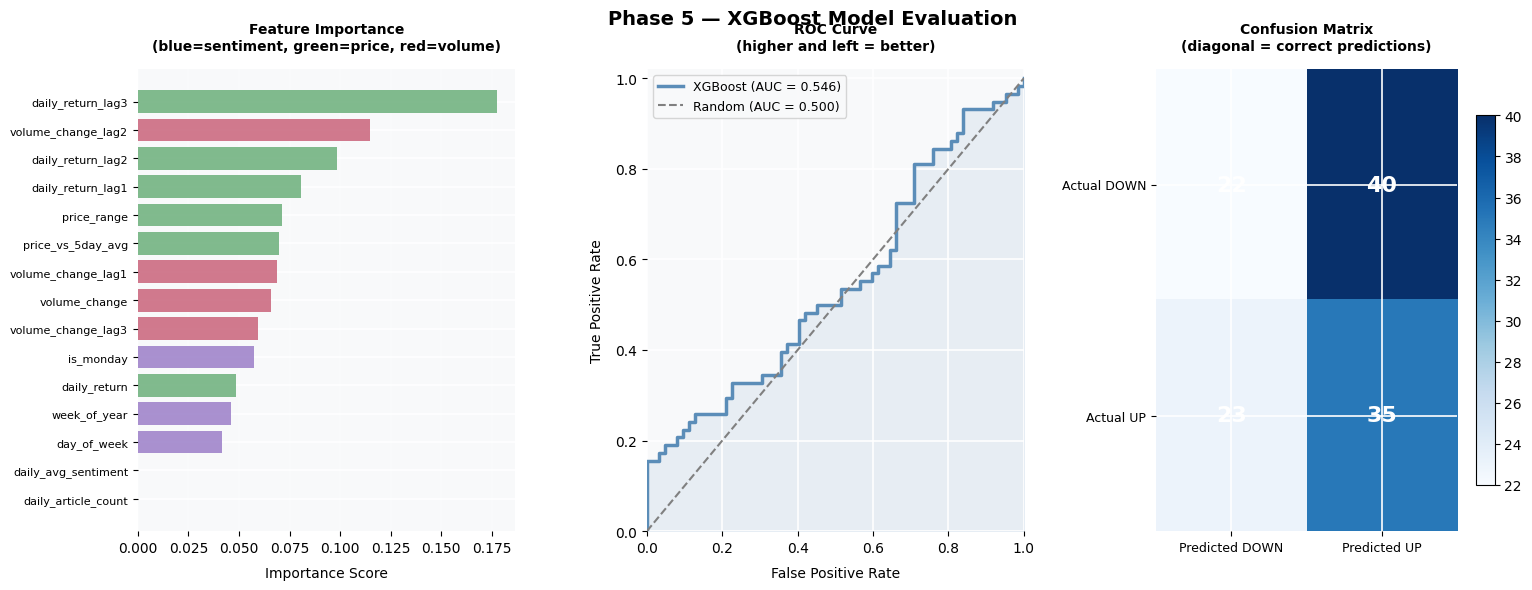

2026-06-08 00:46:13 | src.model            | INFO     | Model saved: d:\Financial-News-Sentiment-Intelligence-System\models\xgboost_sentiment.pkl
2026-06-08 00:46:13 | src.model            | INFO     | Metrics saved: d:\Financial-News-Sentiment-Intelligence-System\models\model_metrics.json
2026-06-08 00:46:13 | src.model            | INFO     | =======================================================
2026-06-08 00:46:13 | src.model            | INFO     | Phase 5 complete
2026-06-08 00:46:13 | src.model            | INFO     | Model accuracy : 47.5%
2026-06-08 00:46:13 | src.model            | INFO     | AUC-ROC        : 0.5462
2026-06-08 00:46:13 | src.model            | INFO     | Model saved to : d:\Financial-News-Sentiment-Intelligence-System\models\xgboost_sentiment.pkl
2026-06-08 00:46:13 | src.model            | INFO     | =======================================================



REBUILD COMPLETE
Accuracy  : 47.5%
AUC-ROC   : 0.5462

Top 5 features:
  1. daily_return_lag3                   0.1775
  2. volume_change_lag2                  0.1149
  3. daily_return_lag2                   0.0984
  4. daily_return_lag1                   0.0806
  5. price_range                         0.0711


In [3]:
import importlib
import src.eda, src.sentiment, src.features, src.model
for mod in [src.eda, src.sentiment, src.features, src.model]:
    importlib.reload(mod)

from src.eda import clean_and_save
from src.sentiment import score_dataset, filter_relevant_articles
from src.features import build_feature_matrix
from src.model import run_full_pipeline
from config import (
    RAW_DATA_PATH, PROCESSED_DATA_PATH,
    SENTIMENT_SAVE_PATH, SENTIMENT_FILTERED_PATH,
    FEATURES_PATH,
)

print("=" * 55)
print("FULL PIPELINE REBUILD")
print("=" * 55)

# step 1: clean
print("\n[1/4] Cleaning...")
df_raw   = pd.read_csv(RAW_DATA_PATH)
df_clean = clean_and_save(df_raw, PROCESSED_DATA_PATH)
print(f"  Raw: {len(df_raw)} → Clean: {len(df_clean)}")
print(f"  Dates: {sorted(df_clean['date_clean'].unique())}")

# step 2: score sentiment
print("\n[2/4] Scoring sentiment...")
df_scored   = score_dataset(df_clean, text_column="title",
                             save_path=SENTIMENT_SAVE_PATH)
df_filtered = filter_relevant_articles(df_scored)
df_filtered.to_csv(SENTIMENT_FILTERED_PATH, index=False)
print(f"  Scored: {len(df_scored)} → Filtered: {len(df_filtered)}")
print(f"  Sentiment dates: {sorted(df_filtered['date_clean'].unique())}")

# step 3: build features
print("\n[3/4] Building features...")
if os.path.exists(FEATURES_PATH):
    os.remove(FEATURES_PATH)
fm = build_feature_matrix(
    sentiment_path=SENTIMENT_FILTERED_PATH,
    save_path=FEATURES_PATH,
)
real_sentiment_rows = (fm["daily_avg_sentiment"] != 0).sum()
print(f"  Feature matrix: {fm.shape}")
print(f"  Rows with real sentiment: {real_sentiment_rows}")

# step 4: retrain
print("\n[4/4] Retraining model...")
model, metrics, feature_names = run_full_pipeline(
    features_path=FEATURES_PATH
)

print("\n" + "=" * 55)
print("REBUILD COMPLETE")
print("=" * 55)
print(f"Accuracy  : {metrics['accuracy']*100:.1f}%")
print(f"AUC-ROC   : {metrics['auc_roc']:.4f}")
print(f"\nTop 5 features:")
for i, (feat, score) in enumerate(
    list(metrics["feature_importance"].items())[:5], 1
):
    tag = " ← SENTIMENT SIGNAL" if "sentiment" in feat else ""
    print(f"  {i}. {feat:<35} {score:.4f}{tag}")